# 第130章: 時間的注意機構の基礎 — 画像から動画へ

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] Spatial AttentionとTemporal Attentionの違いを説明できる
- [ ] 因果的注意マスク（Causal Mask）の仕組みと必要性を理解できる
- [ ] 時空間テンソル (B, T, C, H, W) を自在に操作できる
- [ ] TemporalSelfAttentionをスクラッチで実装できる
- [ ] SpatioTemporalBlockで空間と時間を統合できる

## 🎯 前提知識

- ✅ Notebook 95（ViT / Self-Attention）
- ✅ Notebook 41（U-Net アーキテクチャ）
- ✅ Notebook 35（PyTorch 基礎）

⏱️ **推定学習時間**: 120-150分  
📊 **難易度**: ★★★☆☆（中級）  
🎓 **カテゴリ**: 時空間モデリング基礎

## 目次

1. [なぜ時間的注意機構が必要か？](#section1)
2. [時空間テンソルの基礎](#section2)
3. [Temporal Self-Attentionの実装](#section3)
4. [因果的注意マスク（Causal Mask）](#section4)
5. [SpatioTemporalBlockの構築](#section5)
6. [1D時系列での動作検証](#section6)
7. [まとめとよくあるエラー](#section7)
8. [自己評価クイズ](#quiz)

In [1]:
# ============================================================
# 環境設定
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import warnings

warnings.filterwarnings('ignore')

# 日本語フォント設定
import matplotlib.font_manager as fm

def setup_japanese_font():
    """日本語フォントを設定する"""
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro',
        'Yu Gothic', 'MS Gothic',
        'Noto Sans CJK JP', 'IPAexGothic',
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# 再現性の確保
torch.manual_seed(42)
np.random.seed(42)

# デバイス設定
device = torch.device('cuda' if torch.cuda.is_available() else 
                       'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'✅ ライブラリのインポート完了')
print(f'🖥️ デバイス: {device}')
print(f'📝 日本語フォント: {font_used}')

✅ ライブラリのインポート完了
🖥️ デバイス: cpu
📝 日本語フォント: Yu Gothic


<a id="section1"></a>
## 1. なぜ時間的注意機構が必要か？

### 🤔 画像から動画へ: 何が変わるのか？

これまで私たちは**静止画**を扱ってきました。画像は空間的な情報（幅 × 高さ × チャンネル）を持ちます。

しかし**動画**には、もう1つの軸が加わります。それが **時間** です。

```
画像: (C, H, W)        → 1枚の写真
動画: (T, C, H, W)     → T枚のフレーム列
バッチ: (B, T, C, H, W) → B個の動画
```

空間的なSelf-Attention（Notebook 95で学んだViT）は、**1枚の画像内**でパッチ間の関係を捉えます。
しかし動画では、**異なる時刻のフレーム間**の関係も捉える必要があります。

| 種類 | 対象 | 例 |
|------|------|----|
| Spatial Attention | 同じ時刻内のパッチ間 | 顔の目と口の関係 |
| Temporal Attention | 同じ位置の異なる時刻間 | 歩行中の足の動き |
| Spatiotemporal Attention | 全時空間 | 投げたボールの軌跡 |

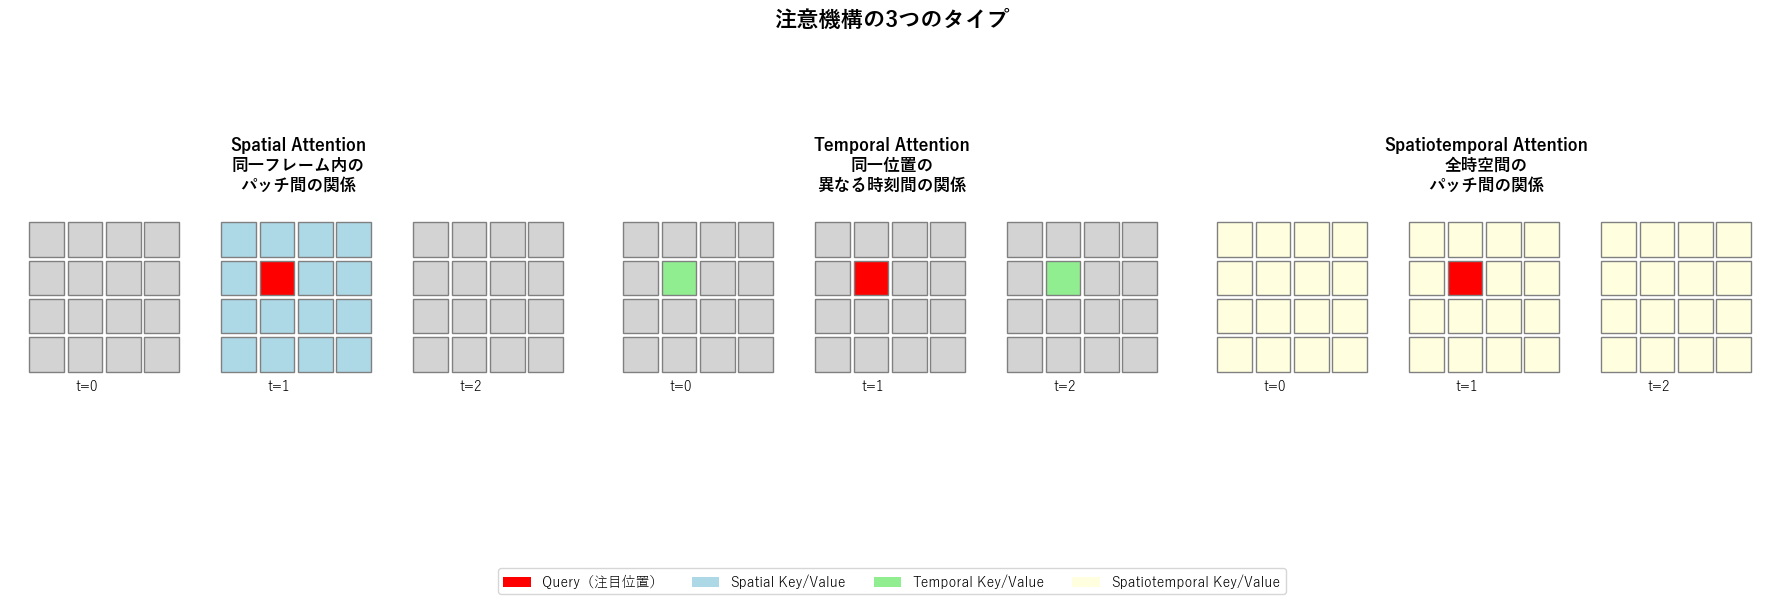

In [2]:
# ============================================================
# 空間的Attentionと時間的Attentionの違いを可視化
# ============================================================

def visualize_attention_types():
    """Spatial / Temporal / Spatiotemporal Attentionの概念図"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 3フレームの動画を表現（4x4グリッド × 3時刻）
    for ax_idx, (ax, title, desc) in enumerate(zip(
        axes, 
        ['Spatial Attention', 'Temporal Attention', 'Spatiotemporal Attention'],
        ['同一フレーム内の\nパッチ間の関係', '同一位置の\n異なる時刻間の関係', '全時空間の\nパッチ間の関係']
    )):
        # 3フレームを描画
        for t in range(3):
            for i in range(4):
                for j in range(4):
                    x = j + t * 5
                    y = 3 - i
                    color = 'lightgray'
                    
                    if ax_idx == 0:  # Spatial: 同じフレーム内
                        if t == 1:
                            color = 'lightblue' if not (i == 1 and j == 1) else 'red'
                    elif ax_idx == 1:  # Temporal: 同じ位置の異なる時刻
                        if i == 1 and j == 1:
                            color = 'lightgreen' if t != 1 else 'red'
                    else:  # Spatiotemporal: 全部
                        if i == 1 and j == 1 and t == 1:
                            color = 'red'
                        else:
                            color = 'lightyellow'
                    
                    rect = plt.Rectangle((x, y), 0.9, 0.9, 
                                         facecolor=color, edgecolor='gray')
                    ax.add_patch(rect)
            # フレームラベル
            ax.text(1.5 + t * 5, -0.5, f't={t}', ha='center', fontsize=10)
        
        ax.set_xlim(-0.5, 14.5)
        ax.set_ylim(-1.2, 4.5)
        ax.set_aspect('equal')
        ax.set_title(f'{title}\n{desc}', fontsize=12, fontweight='bold')
        ax.axis('off')
    
    # 凡例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='Query（注目位置）'),
        Patch(facecolor='lightblue', label='Spatial Key/Value'),
        Patch(facecolor='lightgreen', label='Temporal Key/Value'),
        Patch(facecolor='lightyellow', label='Spatiotemporal Key/Value'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10)
    
    plt.suptitle('注意機構の3つのタイプ', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

visualize_attention_types()

<a id="section2"></a>
## 2. 時空間テンソルの基礎

### 📊 (B, T, C, H, W) テンソルの理解

動画データは5次元テンソルで表現されます：

| 次元 | 意味 | 例 |
|------|------|----|
| B | バッチサイズ | 4（同時に4本の動画を処理） |
| T | フレーム数（時間長） | 16（16フレーム） |
| C | チャンネル数 | 3（RGB）or 特徴次元 |
| H | 高さ | 64 |
| W | 幅 | 64 |

Spatial Attentionでは `(H, W)` 方向に注意を計算し、
Temporal Attentionでは `T` 方向に注意を計算します。

In [3]:
# ============================================================
# 時空間テンソルの基本操作
# ============================================================

# 動画テンソルの作成
B, T, C, H, W = 2, 8, 3, 32, 32
video = torch.randn(B, T, C, H, W)

print("="*60)
print("時空間テンソルの基本操作")
print("="*60)
print(f"動画テンソルの形状: {video.shape}")
print(f"  B={B} (バッチ), T={T} (フレーム), C={C} (チャンネル), H={H}, W={W}")
print(f"  要素数: {video.numel():,}")
print()

# Spatial Attention用のreshape
# (B, T, C, H, W) → (B*T, C, H*W) → 各フレーム内でH*W個のトークン
spatial_tokens = video.reshape(B * T, C, H * W).permute(0, 2, 1)
print(f"Spatial Attention用:")
print(f"  reshape: {video.shape} → {spatial_tokens.shape}")
print(f"  意味: {B*T}フレーム × {H*W}トークン × {C}次元")
print()

# Temporal Attention用のreshape
# (B, T, C, H, W) → (B*H*W, T, C) → 各空間位置でT個のトークン
temporal_tokens = video.permute(0, 3, 4, 1, 2).reshape(B * H * W, T, C)
print(f"Temporal Attention用:")
print(f"  reshape: {video.shape} → {temporal_tokens.shape}")
print(f"  意味: {B*H*W}位置 × {T}フレーム × {C}次元")

時空間テンソルの基本操作
動画テンソルの形状: torch.Size([2, 8, 3, 32, 32])
  B=2 (バッチ), T=8 (フレーム), C=3 (チャンネル), H=32, W=32
  要素数: 49,152

Spatial Attention用:
  reshape: torch.Size([2, 8, 3, 32, 32]) → torch.Size([16, 1024, 3])
  意味: 16フレーム × 1024トークン × 3次元

Temporal Attention用:
  reshape: torch.Size([2, 8, 3, 32, 32]) → torch.Size([2048, 8, 3])
  意味: 2048位置 × 8フレーム × 3次元


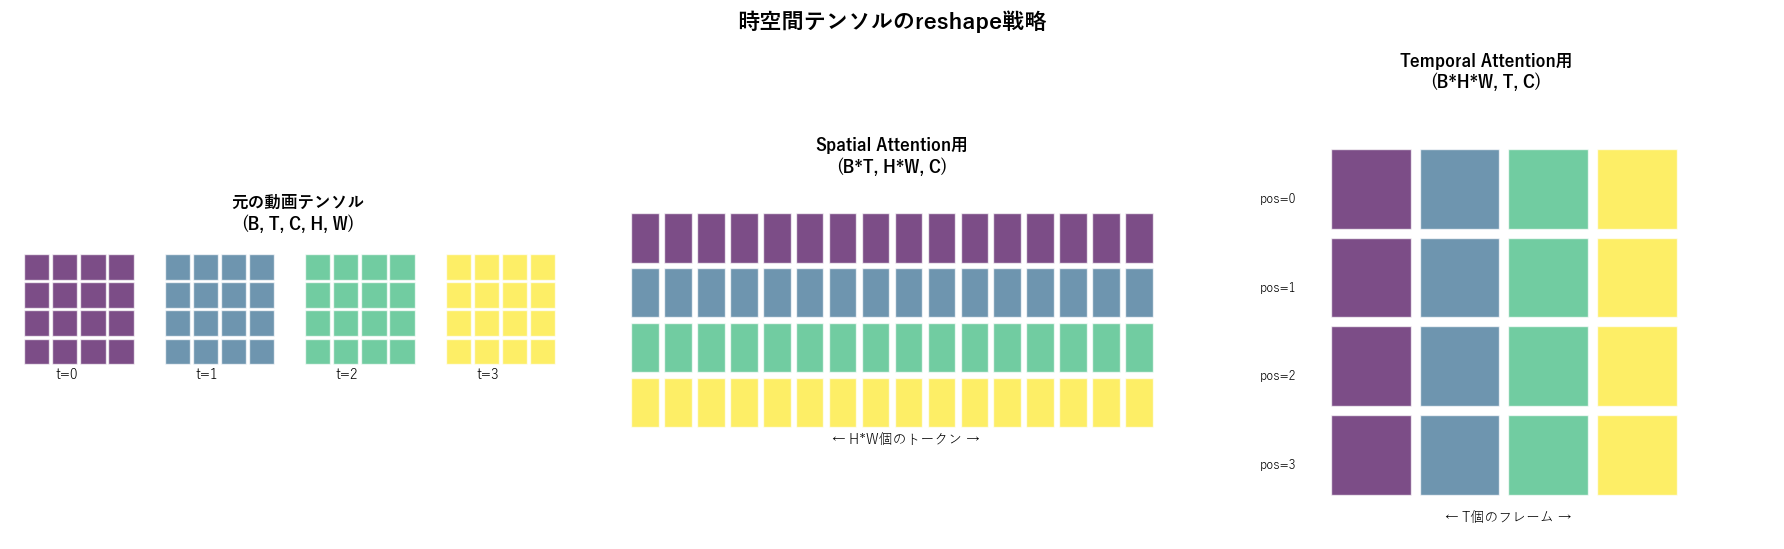

In [4]:
# ============================================================
# テンソル操作の図解
# ============================================================

def visualize_tensor_reshape():
    """時空間テンソルのreshape操作を図解"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. 元の動画テンソル
    ax = axes[0]
    # 4フレーム × 4×4 の動画を表現
    for t in range(4):
        offset_x = t * 5
        for i in range(4):
            for j in range(4):
                color = plt.cm.viridis(t / 3)
                rect = plt.Rectangle((offset_x + j, 3 - i), 0.9, 0.9,
                                     facecolor=color, edgecolor='white', alpha=0.7)
                ax.add_patch(rect)
        ax.text(offset_x + 1.5, -0.5, f't={t}', ha='center', fontsize=10)
    ax.set_xlim(-0.5, 20)
    ax.set_ylim(-1.2, 4.5)
    ax.set_aspect('equal')
    ax.set_title('元の動画テンソル\n(B, T, C, H, W)', fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # 2. Spatial用reshape
    ax = axes[1]
    for t in range(4):
        for idx in range(16):  # H*W = 16
            x = idx
            y = 3 - t
            color = plt.cm.viridis(t / 3)
            rect = plt.Rectangle((x * 0.6, y), 0.5, 0.9,
                                 facecolor=color, edgecolor='white', alpha=0.7)
            ax.add_patch(rect)
    ax.set_xlim(-0.5, 10)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect('equal')
    ax.set_title('Spatial Attention用\n(B*T, H*W, C)', fontsize=12, fontweight='bold')
    ax.text(5, -0.3, '← H*W個のトークン →', ha='center', fontsize=10)
    ax.axis('off')
    
    # 3. Temporal用reshape
    ax = axes[2]
    for pos in range(4):  # 4つの空間位置を例示
        for t in range(4):
            color = plt.cm.viridis(t / 3)
            rect = plt.Rectangle((t, 3 - pos), 0.9, 0.9,
                                 facecolor=color, edgecolor='white', alpha=0.7)
            ax.add_patch(rect)
        ax.text(-0.8, 3 - pos + 0.3, f'pos={pos}', fontsize=9)
    ax.set_xlim(-1.5, 5)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect('equal')
    ax.set_title('Temporal Attention用\n(B*H*W, T, C)', fontsize=12, fontweight='bold')
    ax.text(2, -0.3, '← T個のフレーム →', ha='center', fontsize=10)
    ax.axis('off')
    
    plt.suptitle('時空間テンソルのreshape戦略', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_tensor_reshape()

<a id="section3"></a>
## 3. Temporal Self-Attentionの実装

### 📊 仕組み

Temporal Self-Attentionは、**同じ空間位置**の異なるフレーム間でAttentionを計算します。

$$
\text{TemporalAttention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V
$$

ここで $Q, K, V$ は時間方向のトークン列から生成されます。

ViTのSelf-Attentionとの違いは、入力テンソルのreshape方法だけです。
数式自体は同じAttentionですが、**何に対してAttentionを取るか** が異なります。

In [5]:
# ============================================================
# Temporal Self-Attention の実装
# ============================================================

class TemporalSelfAttention(nn.Module):
    """時間方向のSelf-Attention
    
    同じ空間位置の異なるフレーム間で注意機構を計算する。
    入力: (B, T, C, H, W)
    出力: (B, T, C, H, W)
    """
    
    def __init__(self, dim, num_heads=4, qkv_bias=True):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        # Q, K, V の線形変換
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        # 出力の線形変換
        self.proj = nn.Linear(dim, dim)
        # Layer Normalization
        self.norm = nn.LayerNorm(dim)
    
    def forward(self, x, causal_mask=None):
        """順伝播
        
        Args:
            x: (B, T, C, H, W) の入力テンソル
            causal_mask: オプションの因果マスク (T, T)
        Returns:
            (B, T, C, H, W) の出力テンソル
        """
        B, T, C, H, W = x.shape
        
        # (B, T, C, H, W) → (B*H*W, T, C)
        # 各空間位置ごとに時間方向のAttentionを計算
        x_reshaped = x.permute(0, 3, 4, 1, 2).reshape(B * H * W, T, C)
        
        # 残差接続用に保存
        residual = x_reshaped
        
        # Layer Norm
        x_norm = self.norm(x_reshaped)
        
        # Q, K, V を計算
        qkv = self.qkv(x_norm).reshape(B * H * W, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B*H*W, heads, T, head_dim)
        q, k, v = qkv.unbind(0)  # それぞれ (B*H*W, heads, T, head_dim)
        
        # Attention スコアの計算
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B*H*W, heads, T, T)
        
        # 因果マスクの適用（オプション）
        if causal_mask is not None:
            attn = attn.masked_fill(causal_mask == 0, float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        
        # Attentionの適用
        out = (attn @ v)  # (B*H*W, heads, T, head_dim)
        out = out.transpose(1, 2).reshape(B * H * W, T, C)  # (B*H*W, T, C)
        
        # 出力射影 + 残差接続
        out = self.proj(out) + residual
        
        # (B*H*W, T, C) → (B, T, C, H, W)
        out = out.reshape(B, H, W, T, C).permute(0, 3, 4, 1, 2)
        
        return out

# テスト
B, T, C, H, W = 2, 8, 32, 4, 4
x = torch.randn(B, T, C, H, W)
temporal_attn = TemporalSelfAttention(dim=C, num_heads=4)
out = temporal_attn(x)

print("TemporalSelfAttention テスト:")
print(f"  入力: {x.shape}")
print(f"  出力: {out.shape}")
print(f"  パラメータ数: {sum(p.numel() for p in temporal_attn.parameters()):,}")
print("✅ 入出力の形状が一致！")

TemporalSelfAttention テスト:
  入力: torch.Size([2, 8, 32, 4, 4])
  出力: torch.Size([2, 8, 32, 4, 4])
  パラメータ数: 4,288
✅ 入出力の形状が一致！


### 💡 実装のポイント

上の実装で重要なのは**reshape操作**です:

1. `(B, T, C, H, W)` → `(B*H*W, T, C)` : 空間位置を「バッチ」として畳み込む
2. この形式でAttentionを計算すると、自然に **同じ空間位置の異なる時刻間** でAttentionが取られる
3. 計算後に `(B*H*W, T, C)` → `(B, T, C, H, W)` に戻す

つまり、**reshapeだけでSpatialとTemporalの切り替えができる**のが美しいポイントです。

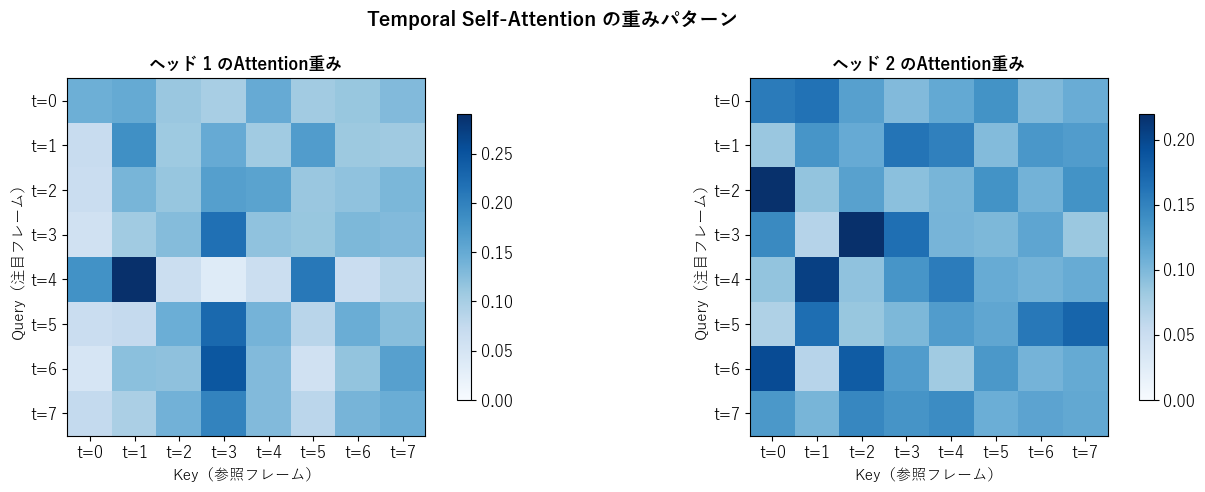

各フレームが他のフレームにどれだけ注目しているかを示しています。
ヘッドごとに異なるパターンを学習することで、多様な時間関係を捉えます。


In [6]:
# ============================================================
# Attention重みの可視化
# ============================================================

def visualize_temporal_attention_weights():
    """Temporal Attentionの重みを可視化"""
    # 小さい例で計算
    T, C = 8, 16
    num_heads = 2
    head_dim = C // num_heads
    
    torch.manual_seed(42)
    # 1つの空間位置の時系列
    x = torch.randn(1, T, C)
    
    # Q, K を生成
    W_qk = nn.Linear(C, C * 2)
    qk = W_qk(x).reshape(1, T, 2, num_heads, head_dim)
    qk = qk.permute(2, 0, 3, 1, 4)
    q, k = qk.unbind(0)
    
    # Attention スコア
    scale = head_dim ** -0.5
    attn = F.softmax((q @ k.transpose(-2, -1)) * scale, dim=-1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for h in range(num_heads):
        ax = axes[h]
        im = ax.imshow(attn[0, h].detach().numpy(), cmap='Blues', vmin=0)
        ax.set_xlabel('Key（参照フレーム）', fontsize=11)
        ax.set_ylabel('Query（注目フレーム）', fontsize=11)
        ax.set_title(f'ヘッド {h+1} のAttention重み', fontsize=12, fontweight='bold')
        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels([f't={t}' for t in range(T)])
        ax.set_yticklabels([f't={t}' for t in range(T)])
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    plt.suptitle('Temporal Self-Attention の重みパターン', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("各フレームが他のフレームにどれだけ注目しているかを示しています。")
    print("ヘッドごとに異なるパターンを学習することで、多様な時間関係を捉えます。")

visualize_temporal_attention_weights()

<a id="section4"></a>
## 4. 因果的注意マスク（Causal Mask）

### 🤔 なぜ因果マスクが必要か？

動画生成では、**未来のフレームを見てはいけない** 場合があります。

- **自己回帰生成**: フレームを1つずつ順番に生成する場合、t=3のフレームはt=0,1,2の情報のみ使用可能
- **リアルタイム処理**: ストリーミング動画では未来のデータはまだ存在しない

因果マスク（Causal Mask）は、各時刻が**過去と現在のみ**参照できるように制約します。

```
通常のAttention（双方向）:     因果マスク（単方向）:
  t0 t1 t2 t3                   t0 t1 t2 t3
t0 ✓  ✓  ✓  ✓                t0 ✓  ✗  ✗  ✗
t1 ✓  ✓  ✓  ✓                t1 ✓  ✓  ✗  ✗
t2 ✓  ✓  ✓  ✓                t2 ✓  ✓  ✓  ✗
t3 ✓  ✓  ✓  ✓                t3 ✓  ✓  ✓  ✓
```

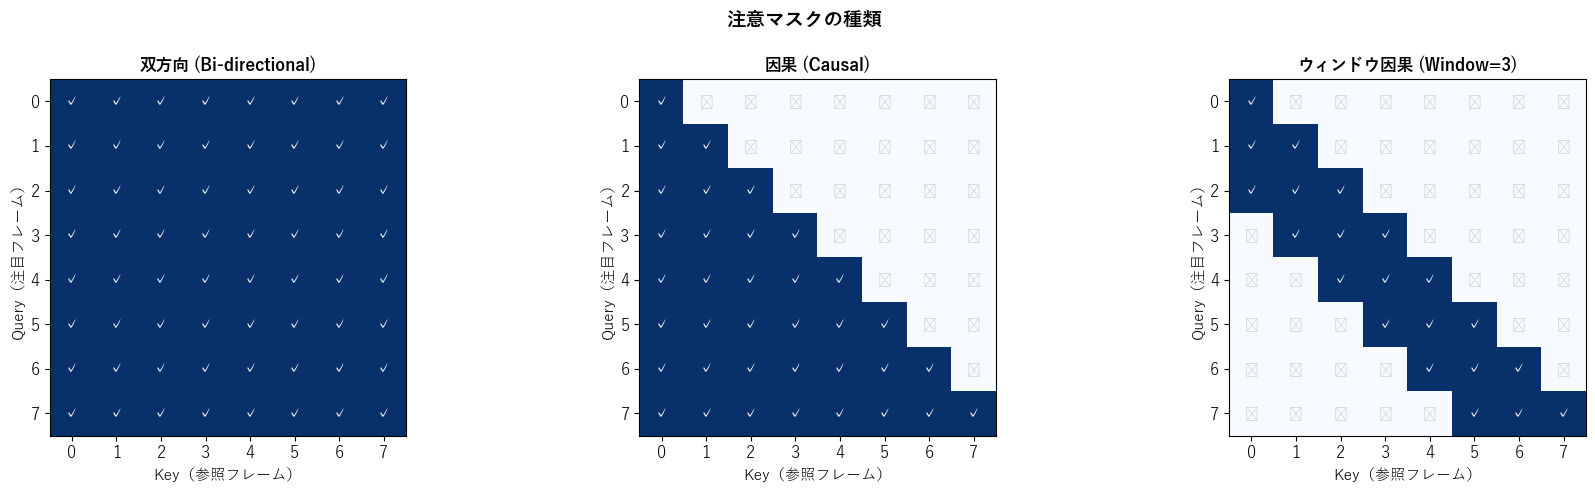

✓ = 参照可能, ✗ = マスク（参照不可）
ウィンドウ因果マスクは、メモリ効率と長い動画への対応に有用です。


In [7]:
# ============================================================
# 因果マスクの生成と可視化
# ============================================================

class CausalMask:
    """因果的注意マスクを生成するユーティリティ"""
    
    @staticmethod
    def create(T, device='cpu'):
        """下三角行列の因果マスクを生成
        
        Args:
            T: シーケンス長（フレーム数）
            device: デバイス
        Returns:
            (T, T) のマスクテンソル（1=参照可能, 0=マスク）
        """
        return torch.tril(torch.ones(T, T, device=device))
    
    @staticmethod
    def create_windowed(T, window_size, device='cpu'):
        """ウィンドウ付き因果マスク（直近のフレームのみ参照）
        
        Args:
            T: シーケンス長
            window_size: 参照可能なウィンドウサイズ
            device: デバイス
        Returns:
            (T, T) のマスクテンソル
        """
        causal = torch.tril(torch.ones(T, T, device=device))
        # window_sizeより古いフレームをマスク
        for i in range(T):
            if i >= window_size:
                causal[i, :i - window_size + 1] = 0
        return causal

# マスクの可視化
T = 8
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

masks = [
    ('双方向 (Bi-directional)', torch.ones(T, T)),
    ('因果 (Causal)', CausalMask.create(T)),
    ('ウィンドウ因果 (Window=3)', CausalMask.create_windowed(T, window_size=3)),
]

for ax, (title, mask) in zip(axes, masks):
    im = ax.imshow(mask.numpy(), cmap='Blues', vmin=0, vmax=1)
    ax.set_xlabel('Key（参照フレーム）', fontsize=11)
    ax.set_ylabel('Query（注目フレーム）', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    # 各セルに値を表示
    for i in range(T):
        for j in range(T):
            ax.text(j, i, '✓' if mask[i, j] > 0 else '✗',
                   ha='center', va='center', fontsize=10,
                   color='white' if mask[i, j] > 0.5 else 'lightgray')

plt.suptitle('注意マスクの種類', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ = 参照可能, ✗ = マスク（参照不可）")
print("ウィンドウ因果マスクは、メモリ効率と長い動画への対応に有用です。")

In [8]:
# ============================================================
# 因果マスク付きAttentionのテスト
# ============================================================

# 因果マスクを適用したTemporalAttention
B, T, C, H, W = 2, 8, 32, 4, 4
x = torch.randn(B, T, C, H, W)

temporal_attn = TemporalSelfAttention(dim=C, num_heads=4)
causal_mask = CausalMask.create(T)

# 因果マスクなし（双方向）
out_bidirectional = temporal_attn(x)

# 因果マスクあり（単方向）
out_causal = temporal_attn(x, causal_mask=causal_mask)

print("因果マスクの効果:")
print(f"  双方向の出力: {out_bidirectional.shape}")
print(f"  因果的の出力: {out_causal.shape}")
print(f"  出力の差異: {(out_bidirectional - out_causal).abs().mean():.4f}")
print("  → 因果マスクにより未来の情報が遮断され、出力が変化している")

因果マスクの効果:
  双方向の出力: torch.Size([2, 8, 32, 4, 4])
  因果的の出力: torch.Size([2, 8, 32, 4, 4])
  出力の差異: 0.0987
  → 因果マスクにより未来の情報が遮断され、出力が変化している


<a id="section5"></a>
## 5. SpatioTemporalBlockの構築

### 📊 空間と時間の統合

実際の動画モデルでは、Spatial AttentionとTemporal Attentionを**交互に適用**します。
これを1つのブロックにまとめたものがSpatioTemporalBlockです。

```
入力: (B, T, C, H, W)
  ↓
[Spatial Self-Attention]  ← 各フレーム内のパッチ間
  ↓
[Temporal Self-Attention] ← 同じ位置の異なるフレーム間
  ↓
[Feed-Forward Network]   ← 各トークンの特徴変換
  ↓
出力: (B, T, C, H, W)
```

この「空間→時間→FFN」のパターンは、Video Diffusion TransformerやSoraの基本構成です。

In [9]:
# ============================================================
# Spatial Self-Attention の実装
# ============================================================

class SpatialSelfAttention(nn.Module):
    """空間方向のSelf-Attention
    
    各フレーム内のH*W個のトークン間で注意機構を計算する。
    入力: (B, T, C, H, W)
    出力: (B, T, C, H, W)
    """
    
    def __init__(self, dim, num_heads=4, qkv_bias=True):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
        self.norm = nn.LayerNorm(dim)
    
    def forward(self, x):
        B, T, C, H, W = x.shape
        
        # (B, T, C, H, W) → (B*T, H*W, C)
        x_reshaped = x.reshape(B * T, C, H * W).permute(0, 2, 1)
        residual = x_reshaped
        
        x_norm = self.norm(x_reshaped)
        
        N = H * W  # トークン数
        qkv = self.qkv(x_norm).reshape(B * T, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        
        attn = F.softmax((q @ k.transpose(-2, -1)) * self.scale, dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B * T, N, C)
        out = self.proj(out) + residual
        
        # (B*T, H*W, C) → (B, T, C, H, W)
        out = out.permute(0, 2, 1).reshape(B, T, C, H, W)
        return out

# テスト
spatial_attn = SpatialSelfAttention(dim=C, num_heads=4)
out_spatial = spatial_attn(x)
print(f"SpatialSelfAttention: {x.shape} → {out_spatial.shape} ✅")

SpatialSelfAttention: torch.Size([2, 8, 32, 4, 4]) → torch.Size([2, 8, 32, 4, 4]) ✅


In [10]:
# ============================================================
# SpatioTemporalBlock の実装
# ============================================================

class SpatioTemporalBlock(nn.Module):
    """時空間Attentionブロック
    
    Spatial Attention → Temporal Attention → FFN の3段構成。
    Video Diffusion ModelやSoraの基本構成要素。
    """
    
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0, use_causal=False):
        super().__init__()
        self.spatial_attn = SpatialSelfAttention(dim, num_heads)
        self.temporal_attn = TemporalSelfAttention(dim, num_heads)
        
        # Feed-Forward Network
        mlp_dim = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim),
        )
        
        self.use_causal = use_causal
    
    def forward(self, x):
        """順伝播
        
        Args:
            x: (B, T, C, H, W)
        Returns:
            (B, T, C, H, W)
        """
        B, T, C, H, W = x.shape
        
        # 1. Spatial Attention
        x = self.spatial_attn(x)
        
        # 2. Temporal Attention（オプションで因果マスク）
        causal_mask = CausalMask.create(T, x.device) if self.use_causal else None
        x = self.temporal_attn(x, causal_mask=causal_mask)
        
        # 3. FFN（各トークンに独立に適用）
        # (B, T, C, H, W) → (B*T*H*W, C) → FFN → (B, T, C, H, W)
        x_flat = x.permute(0, 1, 3, 4, 2).reshape(-1, C)
        x_flat = self.ffn(x_flat) + x_flat  # 残差接続
        x = x_flat.reshape(B, T, H, W, C).permute(0, 1, 4, 2, 3)
        
        return x

# テスト
B, T, C, H, W = 2, 8, 32, 4, 4
x = torch.randn(B, T, C, H, W)

st_block = SpatioTemporalBlock(dim=C, num_heads=4, use_causal=False)
out = st_block(x)

print("="*60)
print("SpatioTemporalBlock テスト")
print("="*60)
print(f"入力: {x.shape}")
print(f"出力: {out.shape}")
print(f"パラメータ数: {sum(p.numel() for p in st_block.parameters()):,}")
print()
print("内部構造:")
print(f"  Spatial Attention: {sum(p.numel() for p in st_block.spatial_attn.parameters()):,}")
print(f"  Temporal Attention: {sum(p.numel() for p in st_block.temporal_attn.parameters()):,}")
print(f"  FFN: {sum(p.numel() for p in st_block.ffn.parameters()):,}")
print("✅ SpatioTemporalBlock 動作確認完了")

SpatioTemporalBlock テスト
入力: torch.Size([2, 8, 32, 4, 4])
出力: torch.Size([2, 8, 32, 4, 4])
パラメータ数: 16,992

内部構造:
  Spatial Attention: 4,288
  Temporal Attention: 4,288
  FFN: 8,416
✅ SpatioTemporalBlock 動作確認完了


<a id="section6"></a>
## 6. 1D時系列での動作検証

### 📊 簡単な時系列で理解を深める

高次元の動画データの前に、まず **1D時系列** でTemporal Attentionの動作を確認しましょう。
サイン波+ノイズのシーケンスを入力し、Attentionがどのフレームに注目するかを観察します。

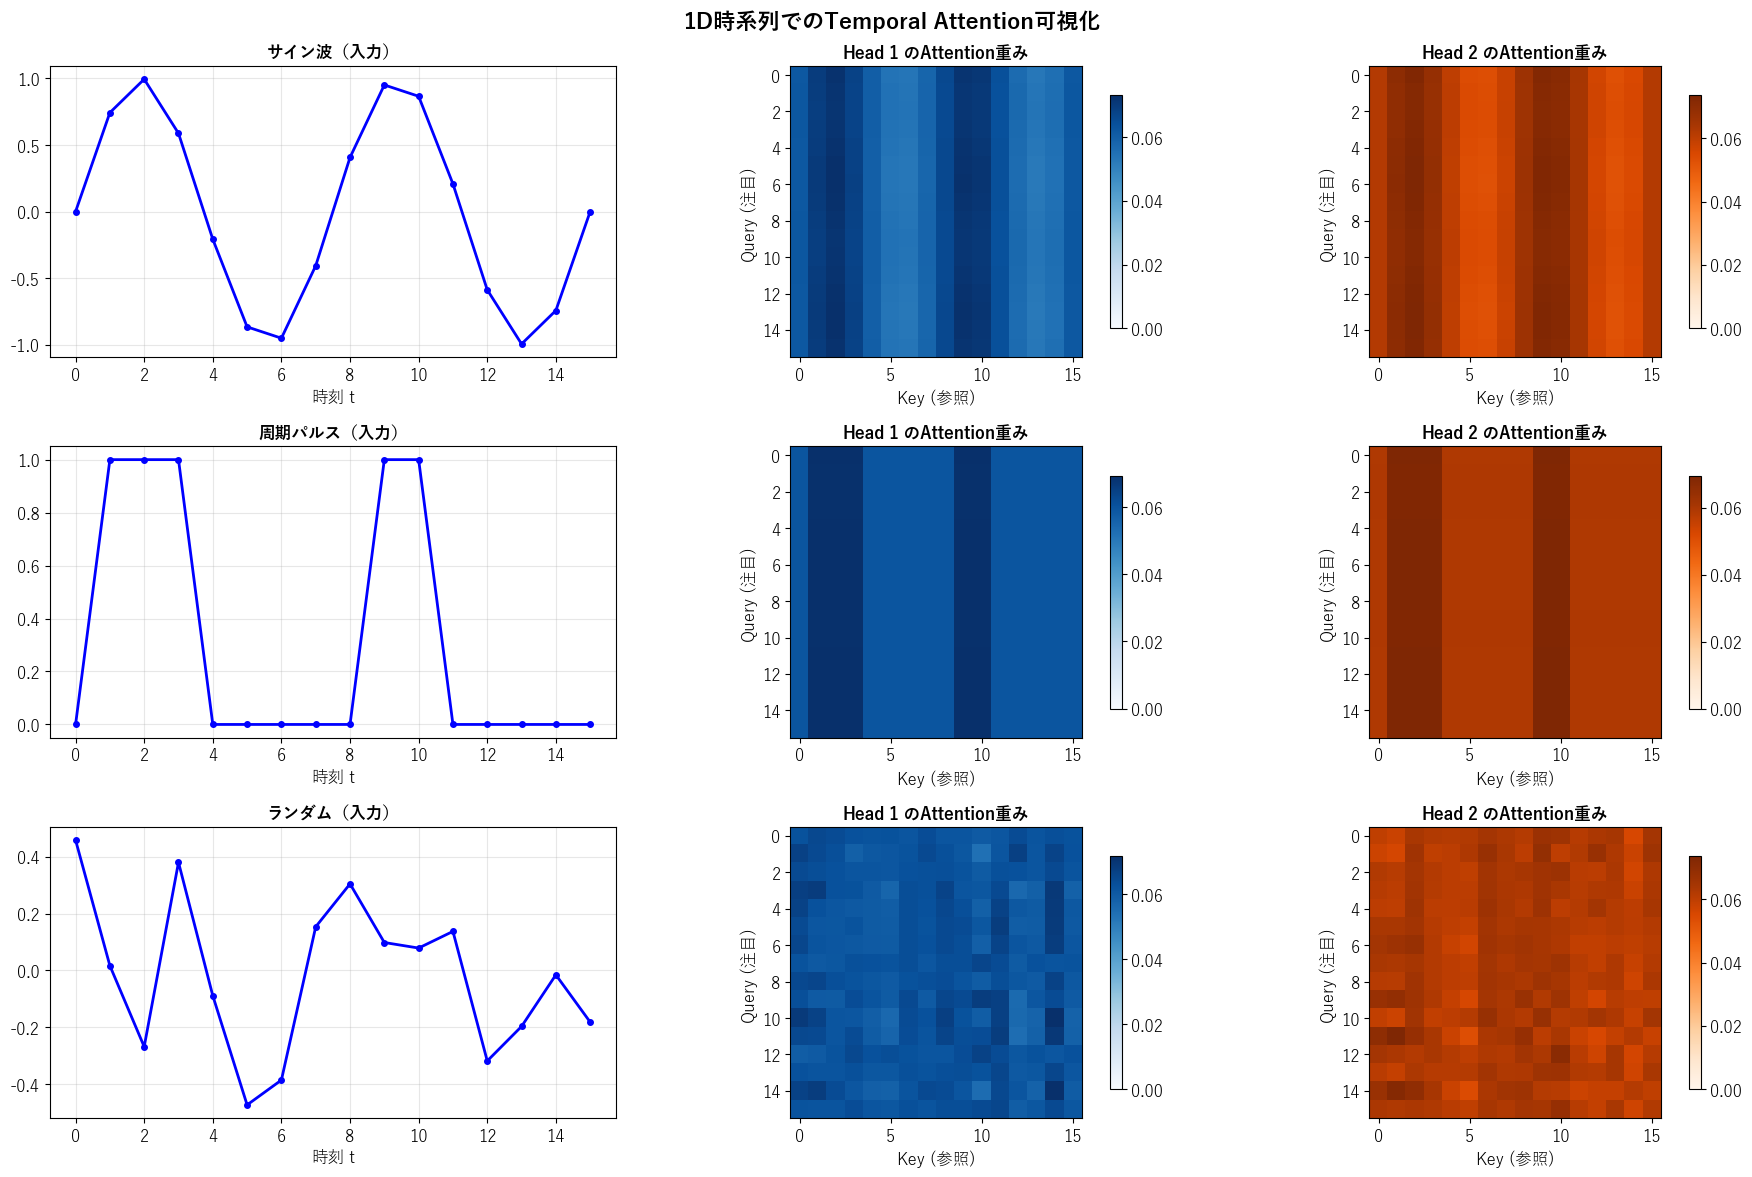

観察ポイント:
- 各ヘッドが異なるパターンに注目している
- 周期的な信号では、同じ位相のフレーム同士の注目度が高くなる傾向がある
- ランダム信号では、Attention重みが比較的均一に分散する


In [11]:
# ============================================================
# 1D時系列でのTemporal Attention検証
# ============================================================

class SimpleTemporalAttention1D(nn.Module):
    """1D時系列用のシンプルなTemporal Attention"""
    
    def __init__(self, dim, num_heads=2):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    
    def forward(self, x):
        """x: (B, T, C) → (B, T, C), attention: (B, heads, T, T)"""
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        
        attn = F.softmax((q @ k.transpose(-2, -1)) * self.scale, dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out), attn

# サイン波 + ノイズの時系列を生成
T = 16
C = 8
t = torch.linspace(0, 4 * np.pi, T)

# 3種類の時系列パターン
patterns = {
    'サイン波': torch.sin(t).unsqueeze(-1).expand(-1, C),
    '周期パルス': (torch.sin(t) > 0.5).float().unsqueeze(-1).expand(-1, C),
    'ランダム': torch.randn(T, C) * 0.3,
}

model = SimpleTemporalAttention1D(dim=C, num_heads=2)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row, (name, signal) in enumerate(patterns.items()):
    x_input = signal.unsqueeze(0)  # (1, T, C)
    with torch.no_grad():
        out, attn = model(x_input)
    
    # 入力信号
    axes[row, 0].plot(signal[:, 0].numpy(), 'b-o', markersize=4, linewidth=2)
    axes[row, 0].set_title(f'{name}（入力）', fontsize=12, fontweight='bold')
    axes[row, 0].set_xlabel('時刻 t')
    axes[row, 0].grid(True, alpha=0.3)
    
    # Head 1のAttention
    im1 = axes[row, 1].imshow(attn[0, 0].numpy(), cmap='Blues', vmin=0)
    axes[row, 1].set_title(f'Head 1 のAttention重み', fontsize=12, fontweight='bold')
    axes[row, 1].set_xlabel('Key (参照)')
    axes[row, 1].set_ylabel('Query (注目)')
    plt.colorbar(im1, ax=axes[row, 1], shrink=0.8)
    
    # Head 2のAttention
    im2 = axes[row, 2].imshow(attn[0, 1].numpy(), cmap='Oranges', vmin=0)
    axes[row, 2].set_title(f'Head 2 のAttention重み', fontsize=12, fontweight='bold')
    axes[row, 2].set_xlabel('Key (参照)')
    axes[row, 2].set_ylabel('Query (注目)')
    plt.colorbar(im2, ax=axes[row, 2], shrink=0.8)

plt.suptitle('1D時系列でのTemporal Attention可視化', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("観察ポイント:")
print("- 各ヘッドが異なるパターンに注目している")
print("- 周期的な信号では、同じ位相のフレーム同士の注目度が高くなる傾向がある")
print("- ランダム信号では、Attention重みが比較的均一に分散する")

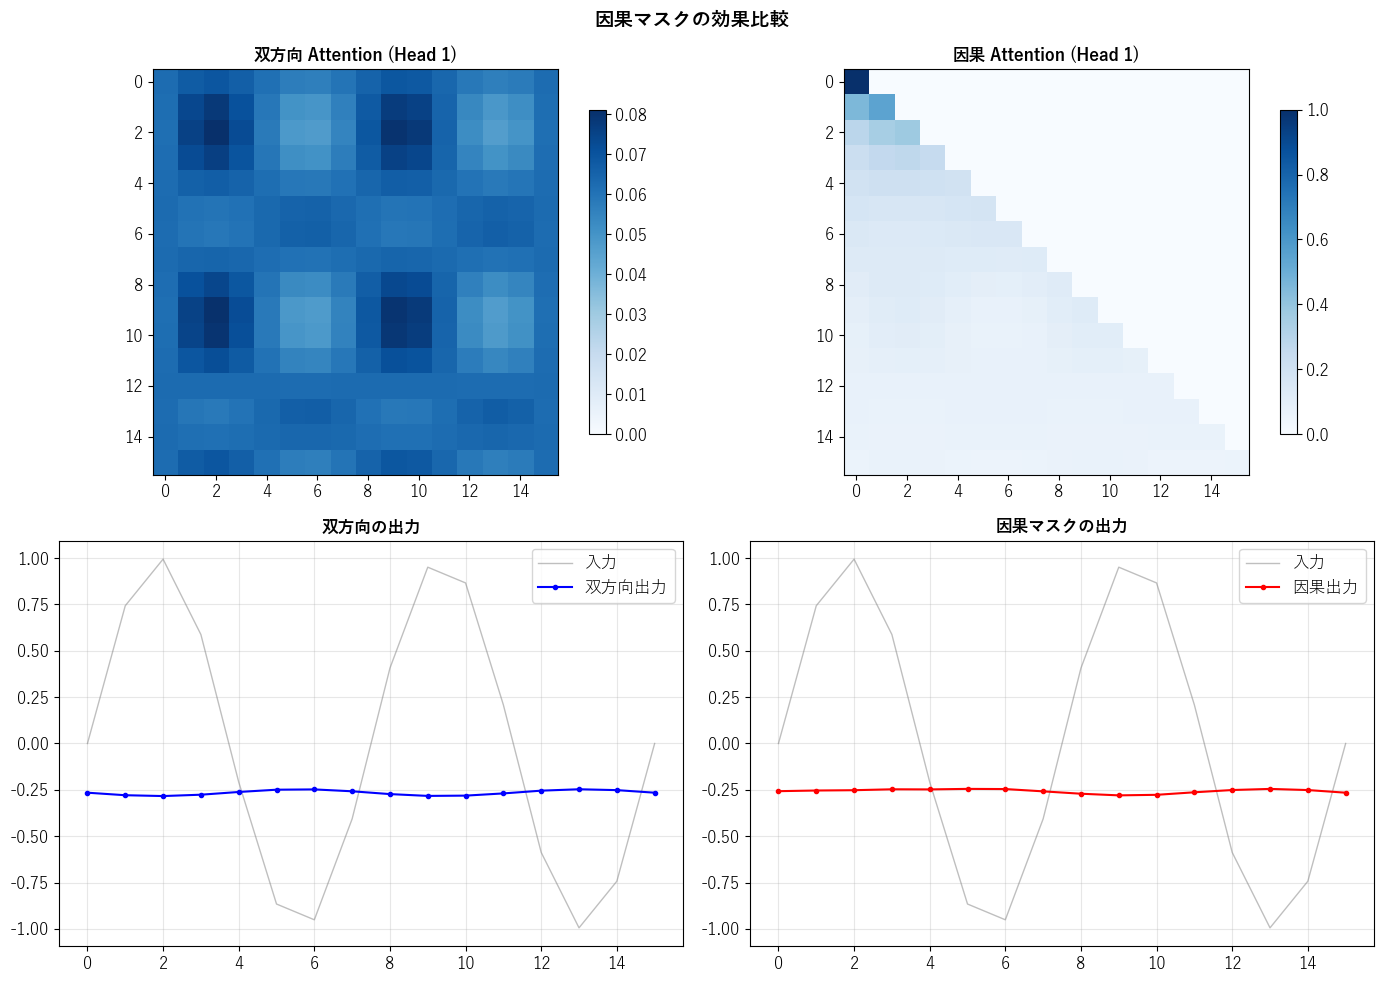

因果マスクのAttention重み行列が下三角形になっていることを確認してください。
因果出力では、序盤のフレームは参照できる情報が少ないため出力が異なります。


In [12]:
# ============================================================
# 因果マスクの効果を1D時系列で確認
# ============================================================

def compare_causal_effect():
    """因果マスクの有無による出力の違いを可視化"""
    T, C = 16, 8
    model = SimpleTemporalAttention1D(dim=C, num_heads=2)
    
    # サイン波入力
    t = torch.linspace(0, 4 * np.pi, T)
    signal = torch.sin(t).unsqueeze(-1).expand(-1, C).unsqueeze(0)
    
    with torch.no_grad():
        # 双方向
        out_bi, attn_bi = model(signal)
        
        # 因果マスクを手動で適用
        B_s, T_s, C_s = signal.shape
        qkv = model.qkv(signal).reshape(B_s, T_s, 3, model.num_heads, model.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        scores = (q @ k.transpose(-2, -1)) * model.scale
        causal = torch.tril(torch.ones(T_s, T_s))
        scores = scores.masked_fill(causal == 0, float('-inf'))
        attn_causal = F.softmax(scores, dim=-1)
        out_causal = (attn_causal @ v).transpose(1, 2).reshape(B_s, T_s, C_s)
        out_causal = model.proj(out_causal)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Attention重みの比較
    im1 = axes[0, 0].imshow(attn_bi[0, 0].numpy(), cmap='Blues', vmin=0)
    axes[0, 0].set_title('双方向 Attention (Head 1)', fontsize=12, fontweight='bold')
    plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)
    
    im2 = axes[0, 1].imshow(attn_causal[0, 0].numpy(), cmap='Blues', vmin=0)
    axes[0, 1].set_title('因果 Attention (Head 1)', fontsize=12, fontweight='bold')
    plt.colorbar(im2, ax=axes[0, 1], shrink=0.8)
    
    # 出力の比較
    axes[1, 0].plot(signal[0, :, 0].numpy(), 'gray', linewidth=1, label='入力', alpha=0.5)
    axes[1, 0].plot(out_bi[0, :, 0].numpy(), 'b-o', markersize=3, label='双方向出力')
    axes[1, 0].set_title('双方向の出力', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(signal[0, :, 0].numpy(), 'gray', linewidth=1, label='入力', alpha=0.5)
    axes[1, 1].plot(out_causal[0, :, 0].numpy(), 'r-o', markersize=3, label='因果出力')
    axes[1, 1].set_title('因果マスクの出力', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('因果マスクの効果比較', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("因果マスクのAttention重み行列が下三角形になっていることを確認してください。")
    print("因果出力では、序盤のフレームは参照できる情報が少ないため出力が異なります。")

compare_causal_effect()

Attention計算量の比較

小（16フレーム, 64×64）:
  Spatial Attention:            268,435,456 (0.27G)
  Temporal Attention:             1,048,576 (0.00G)
  Full Spatiotemporal:        4,294,967,296 (4.29G)
  分離 vs Full の比率: 0.062744

中（32フレーム, 128×128）:
  Spatial Attention:          8,589,934,592 (8.59G)
  Temporal Attention:            16,777,216 (0.02G)
  Full Spatiotemporal:      274,877,906,944 (274.88G)
  分離 vs Full の比率: 0.031311

大（64フレーム, 256×256）:
  Spatial Attention:        274,877,906,944 (274.88G)
  Temporal Attention:           268,435,456 (0.27G)
  Full Spatiotemporal:      17,592,186,044,416 (17592.19G)
  分離 vs Full の比率: 0.015640



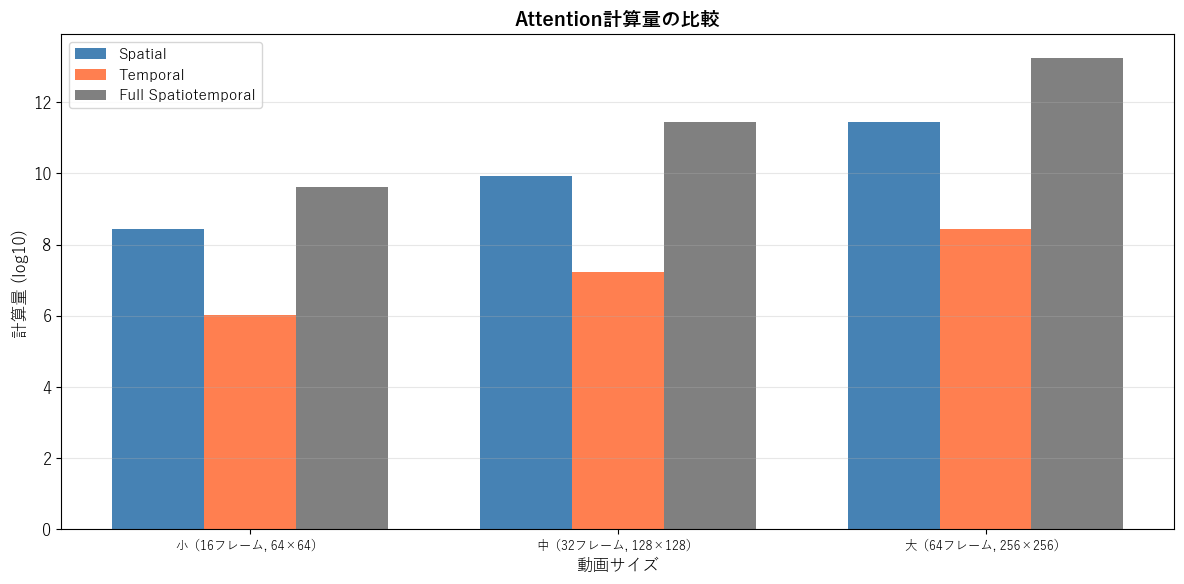

💡 Spatial + Temporal の分離（factorized）により、
   Full Spatiotemporalに比べて計算量を大幅に削減できます。


In [13]:
# ============================================================
# 計算量の比較
# ============================================================

def analyze_complexity():
    """各Attentionの計算量を比較"""
    print("="*60)
    print("Attention計算量の比較")
    print("="*60)
    print()
    
    configs = [
        (16, 64, 64, "小（16フレーム, 64×64）"),
        (32, 128, 128, "中（32フレーム, 128×128）"),
        (64, 256, 256, "大（64フレーム, 256×256）"),
    ]
    
    results = []
    for T, H, W, label in configs:
        N = H * W  # 空間トークン数
        
        # Spatial: O(T * N^2) = 各フレームでN^2のAttention
        spatial_flops = T * N * N
        
        # Temporal: O(N * T^2) = 各空間位置でT^2のAttention
        temporal_flops = N * T * T
        
        # Full Spatiotemporal: O((T*N)^2) = 全トークン間
        full_flops = (T * N) ** 2
        
        results.append((label, spatial_flops, temporal_flops, full_flops))
        
        print(f"{label}:")
        print(f"  Spatial Attention:        {spatial_flops:>15,} ({spatial_flops/1e9:.2f}G)")
        print(f"  Temporal Attention:       {temporal_flops:>15,} ({temporal_flops/1e9:.2f}G)")
        print(f"  Full Spatiotemporal:      {full_flops:>15,} ({full_flops/1e9:.2f}G)")
        print(f"  分離 vs Full の比率: {(spatial_flops + temporal_flops) / full_flops:.6f}")
        print()
    
    # 棒グラフ
    fig, ax = plt.subplots(figsize=(12, 6))
    labels = [r[0] for r in results]
    x = np.arange(len(labels))
    width = 0.25
    
    spatial = [np.log10(r[1]) for r in results]
    temporal = [np.log10(r[2]) for r in results]
    full = [np.log10(r[3]) for r in results]
    
    ax.bar(x - width, spatial, width, label='Spatial', color='steelblue')
    ax.bar(x, temporal, width, label='Temporal', color='coral')
    ax.bar(x + width, full, width, label='Full Spatiotemporal', color='gray')
    
    ax.set_xlabel('動画サイズ', fontsize=12)
    ax.set_ylabel('計算量 (log10)', fontsize=12)
    ax.set_title('Attention計算量の比較', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("💡 Spatial + Temporal の分離（factorized）により、")
    print("   Full Spatiotemporalに比べて計算量を大幅に削減できます。")

analyze_complexity()

<a id="section7"></a>
## 7. まとめとよくあるエラー

### 🎯 このノートブックで学んだこと

**時間的注意機構の基礎**
- ✓ Spatial Attention：同じフレーム内の空間的関係
- ✓ Temporal Attention：同じ位置の異なるフレーム間の関係
- ✓ reshapeだけでSpatial/Temporalを切り替えられる

**因果マスク**
- ✓ 未来のフレームを参照できないように制約する下三角マスク
- ✓ 自己回帰生成やストリーミング処理に必須

**SpatioTemporalBlock**
- ✓ Spatial → Temporal → FFN の3段構成
- ✓ 計算量を分離（factorize）することで効率化

### 📊 チートシート

| 操作 | reshape | 計算量 |
|------|---------|--------|
| Spatial Attention | (B,T,C,H,W) → (B*T, H*W, C) | O(T * (HW)²) |
| Temporal Attention | (B,T,C,H,W) → (B*H*W, T, C) | O(HW * T²) |
| Full Spatiotemporal | (B,T,C,H,W) → (B, T*H*W, C) | O((THW)²) |

### ⚠️ よくあるエラー

#### エラー #1: テンソルの次元順序の間違い

```python
# ❌ 間違い: PyTorchのConv2dは (B, C, H, W) だが動画テンソルは (B, T, C, H, W)
video = torch.randn(2, 8, 3, 64, 64)  # (B, T, C, H, W)
conv = nn.Conv2d(3, 16, 3, padding=1)
out = conv(video)  # エラー！5次元テンソルを受け取れない

# ✅ 正解: reshapeしてからConv2dに通す
B, T, C, H, W = video.shape
video_flat = video.reshape(B * T, C, H, W)  # (B*T, C, H, W)
out = conv(video_flat)  # OK
out = out.reshape(B, T, -1, H, W)  # 元に戻す
```

#### エラー #2: Attention のスケーリング忘れ

```python
# ❌ スケーリングなし → softmaxが飽和し学習が不安定に
attn = softmax(Q @ K.T)

# ✅ √d_k でスケーリング
attn = softmax(Q @ K.T / sqrt(d_k))
```

#### エラー #3: 因果マスクの方向

```python
# ❌ 上三角 → 未来しか見えない
mask = torch.triu(torch.ones(T, T))

# ✅ 下三角 → 過去と現在を見る
mask = torch.tril(torch.ones(T, T))
```

<a id="quiz"></a>
## 🎓 自己評価クイズ

### Q1: Spatial AttentionとTemporal Attentionの主な違いは何ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: Attentionを計算する軸が異なります。

- **Spatial Attention**: 同一フレーム内の空間的なトークン(H×W)間でAttentionを計算。reshape: `(B*T, H*W, C)`
- **Temporal Attention**: 同一空間位置の異なるフレーム(T)間でAttentionを計算。reshape: `(B*H*W, T, C)`

数式自体は同じAttentionですが、テンソルのreshapeで対象を変えています。

</details>

---

### Q2: 因果マスクはどのような場合に必要ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: フレームを時間順に**自己回帰的に生成**する場合や、**リアルタイムストリーミング**処理の場合です。

因果マスクにより、各時刻のフレームは過去と現在の情報のみを使用でき、未来の情報が漏洩しません。
逆に、動画全体を一括で処理する場合（エンコード時など）は双方向Attentionの方が高品質です。

</details>

---

### Q3: Spatial + Temporal の分離（factorized attention）のメリットは？

<details>
<summary>💡 答えを見る</summary>

**答え**: 計算量の大幅な削減です。

- Full Spatiotemporal: O((T×H×W)²)
- Factorized (Spatial + Temporal): O(T×(H×W)² + H×W×T²)

例えば T=16, H=W=64 の場合、Full は約 10^12 に対し、Factorized は約 10^9 と約1000倍高速です。

</details>

---

### Q4: テンソル (B, T, C, H, W) をTemporal Attention用にreshapeする正しい手順は？

<details>
<summary>💡 答えを見る</summary>

**答え**: `x.permute(0, 3, 4, 1, 2).reshape(B*H*W, T, C)`

1. `permute(0, 3, 4, 1, 2)` で `(B, H, W, T, C)` に並べ替え
2. `reshape(B*H*W, T, C)` で空間位置をバッチ次元に畳み込む
3. これにより「各空間位置のT個の時系列」に対してAttentionが計算される

</details>

---

### Q5: SpatioTemporalBlockの3段構成は何ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: Spatial Self-Attention → Temporal Self-Attention → Feed-Forward Network

1. **Spatial Attention**: 各フレーム内のパッチ間の関係を捉える
2. **Temporal Attention**: 同じ位置の異なるフレーム間の関係を捉える
3. **FFN**: 各トークンの特徴を非線形変換する

この構成はVideo Diffusion TransformerやSoraの基本パターンです。

</details>

---

### ✅ 学習チェックリスト

- [ ] Spatial / Temporal / Spatiotemporal Attention の違いを図で説明できる
- [ ] (B,T,C,H,W) テンソルを各Attention用にreshapeできる
- [ ] TemporalSelfAttentionをスクラッチで実装できた
- [ ] 因果マスクの生成と適用ができた
- [ ] SpatioTemporalBlockの構成を理解した

---

**次のステップ**: Notebook 131 では、ここで学んだ時間的注意機構を**U-Net拡散モデル**に組み込み、
**Video Diffusion Model** として動画を生成する方法を学びます！